In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://sundowner.colorado.edu/weather/atoc1/wxobs20051004.txt"

df = pd.read_fwf(url, header=[0, 1], skiprows=[2])

date_col = [c for c in df.columns if c[1] == "Date"][0]
time_col = [c for c in df.columns if c[1] == "Time"][0]

t = (
    df[time_col]
    .astype(str)
    .str.strip()
    .str.replace(r"a$", "AM", regex=True)
    .str.replace(r"p$", "PM", regex=True)
)

dt = pd.to_datetime(
    df[date_col].astype(str).str.strip() + " " + t,
    format="%m/%d/%y %I:%M%p",
    errors="coerce",
)

df = df.set_index(dt).drop(columns=[date_col, time_col])
df.index.name = "datetime"

df.columns = [
    "_".join([str(a).strip(), str(b).strip()]).replace(" ", "_").strip("_")
    for a, b in df.columns
]

df.head()

,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt.,Wind_Speed,Wind_Dir,Wind_Run,Hi_Speed,Hi_Dir,...,Solar_Rad..1,Heat_D-D,Cool_D-D,In_Temp,In_Hum,Unnamed:_27_level_0_ET,Wind_Samp,Wind_Tx,ISS_Recept,Arc._Int.
datetime,,,,,,,,,,,,,,,,,,,,,
2005-10-03 00:05:00,67.8,68.6,67.8,26,31.6,2.0,N,0.17,5.0,NNE,...,0,0.000,0.010,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:10:00,65.5,67.8,65.5,30,33.2,3.0,NNE,0.25,11.0,ENE,...,0,0.000,0.002,67.2,23,0.0,107,1,93.9,5
2005-10-03 00:15:00,63.4,65.3,63.4,33,33.8,3.0,NNW,0.25,9.0,N,...,0,0.006,0.000,67.2,24,0.0,113,1,99.1,5
2005-10-03 00:20:00,62.3,63.2,62.3,35,34.3,1.0,NNE,0.08,7.0,N,...,0,0.009,0.000,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:25:00,61.8,62.3,61.8,37,35.2,0.0,ENE,0.00,2.0,ENE,...,0,0.011,0.000,67.2,25,0.0,109,1,95.6,5


In [7]:
print(df.columns.tolist())

['Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt.', 'Wind_Speed', 'Wind_Dir', 'Wind_Run', 'Hi_Speed', 'Hi_Dir', 'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index', 'Unnamed:_16_level_0_Bar', 'Unnamed:_17_level_0_Rain', 'Rain_Rate', 'Solar_Rad.', 'Solar_Energy', 'Hi_Unnamed:_21_level_1', 'Solar_Rad..1', 'Heat_D-D', 'Cool_D-D', 'In_Temp', 'In_Hum', 'Unnamed:_27_level_0_ET', 'Wind_Samp', 'Wind_Tx', 'ISS_Recept', 'Arc._Int.']


In [8]:
weather = df.copy()
weather = weather.apply(pd.to_numeric, errors="coerce")
weather = weather.dropna(how="all")

weather.head()

,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt.,Wind_Speed,Wind_Dir,Wind_Run,Hi_Speed,Hi_Dir,...,Solar_Rad..1,Heat_D-D,Cool_D-D,In_Temp,In_Hum,Unnamed:_27_level_0_ET,Wind_Samp,Wind_Tx,ISS_Recept,Arc._Int.
datetime,,,,,,,,,,,,,,,,,,,,,
2005-10-03 00:05:00,67.8,68.6,67.8,26,31.6,2.0,NaN,0.17,5.0,NaN,...,0,0.000,0.010,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:10:00,65.5,67.8,65.5,30,33.2,3.0,NaN,0.25,11.0,NaN,...,0,0.000,0.002,67.2,23,0.0,107,1,93.9,5
2005-10-03 00:15:00,63.4,65.3,63.4,33,33.8,3.0,NaN,0.25,9.0,NaN,...,0,0.006,0.000,67.2,24,0.0,113,1,99.1,5
2005-10-03 00:20:00,62.3,63.2,62.3,35,34.3,1.0,NaN,0.08,7.0,NaN,...,0,0.009,0.000,67.2,24,0.0,110,1,96.5,5
2005-10-03 00:25:00,61.8,62.3,61.8,37,35.2,0.0,NaN,0.00,2.0,NaN,...,0,0.011,0.000,67.2,25,0.0,109,1,95.6,5


In [9]:
print(df.columns.tolist())

['Temp_Out', 'Hi_Temp', 'Low_Temp', 'Out_Hum', 'Dew_Pt.', 'Wind_Speed', 'Wind_Dir', 'Wind_Run', 'Hi_Speed', 'Hi_Dir', 'Wind_Chill', 'Heat_Index', 'THW_Index', 'THSW_Index', 'Unnamed:_16_level_0_Bar', 'Unnamed:_17_level_0_Rain', 'Rain_Rate', 'Solar_Rad.', 'Solar_Energy', 'Hi_Unnamed:_21_level_1', 'Solar_Rad..1', 'Heat_D-D', 'Cool_D-D', 'In_Temp', 'In_Hum', 'Unnamed:_27_level_0_ET', 'Wind_Samp', 'Wind_Tx', 'ISS_Recept', 'Arc._Int.']


In [10]:
df[['Unnamed:_17_level_0_Rain', 'Rain_Rate']].head(20)
df[['Unnamed:_17_level_0_Rain', 'Rain_Rate']].describe()



,Unnamed:_17_level_0_Rain,Rain_Rate
count,575.000000,575.000000
mean,0.000313,0.004939
std,0.002021,0.031189
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,0.020000,0.360000


In [11]:
weather = df.copy()
weather = weather.apply(pd.to_numeric, errors='coerce')
weather = weather.dropna(how='all')

# Define columns
temp_col = 'Temp_Out'
dew_col = 'Dew_Pt.'
rh_col = 'Out_Hum'
wind_col = 'Wind_Speed'
gust_col = 'Hi_Speed'
wdir_col = 'Wind_Dir'
solar_col = 'Solar_Rad.'
rain_col = 'Unnamed:_17_level_0_Rain'   # change this if needed after inspection

# Rolling mean for temperature
weather['temp_24h'] = weather[temp_col].rolling('24h').mean()

# Daily anomaly
weather['date'] = weather.index.date
weather['daily_mean_temp'] = weather.groupby('date')[temp_col].transform('mean')
weather['temp_anomaly'] = weather[temp_col] - weather['daily_mean_temp']

# Rain step and cumulative rain
weather['rain_step'] = weather[rain_col].diff()
weather.loc[weather['rain_step'] < 0, 'rain_step'] = 0
weather['rain_step'] = weather['rain_step'].fillna(0)
weather['cumulative_rain'] = weather['rain_step'].cumsum()

weather.head()

,Temp_Out,Hi_Temp,Low_Temp,Out_Hum,Dew_Pt.,Wind_Speed,Wind_Dir,Wind_Run,Hi_Speed,Hi_Dir,...,Wind_Samp,Wind_Tx,ISS_Recept,Arc._Int.,temp_24h,date,daily_mean_temp,temp_anomaly,rain_step,cumulative_rain
datetime,,,,,,,,,,,,,,,,,,,,,
2005-10-03 00:05:00,67.8,68.6,67.8,26,31.6,2.0,NaN,0.17,5.0,NaN,...,110,1,96.5,5,67.800000,2005-10-03,63.743206,4.056794,0.0,0.0
2005-10-03 00:10:00,65.5,67.8,65.5,30,33.2,3.0,NaN,0.25,11.0,NaN,...,107,1,93.9,5,66.650000,2005-10-03,63.743206,1.756794,0.0,0.0
2005-10-03 00:15:00,63.4,65.3,63.4,33,33.8,3.0,NaN,0.25,9.0,NaN,...,113,1,99.1,5,65.566667,2005-10-03,63.743206,-0.343206,0.0,0.0
2005-10-03 00:20:00,62.3,63.2,62.3,35,34.3,1.0,NaN,0.08,7.0,NaN,...,110,1,96.5,5,64.750000,2005-10-03,63.743206,-1.443206,0.0,0.0
2005-10-03 00:25:00,61.8,62.3,61.8,37,35.2,0.0,NaN,0.00,2.0,NaN,...,109,1,95.6,5,64.160000,2005-10-03,63.743206,-1.943206,0.0,0.0


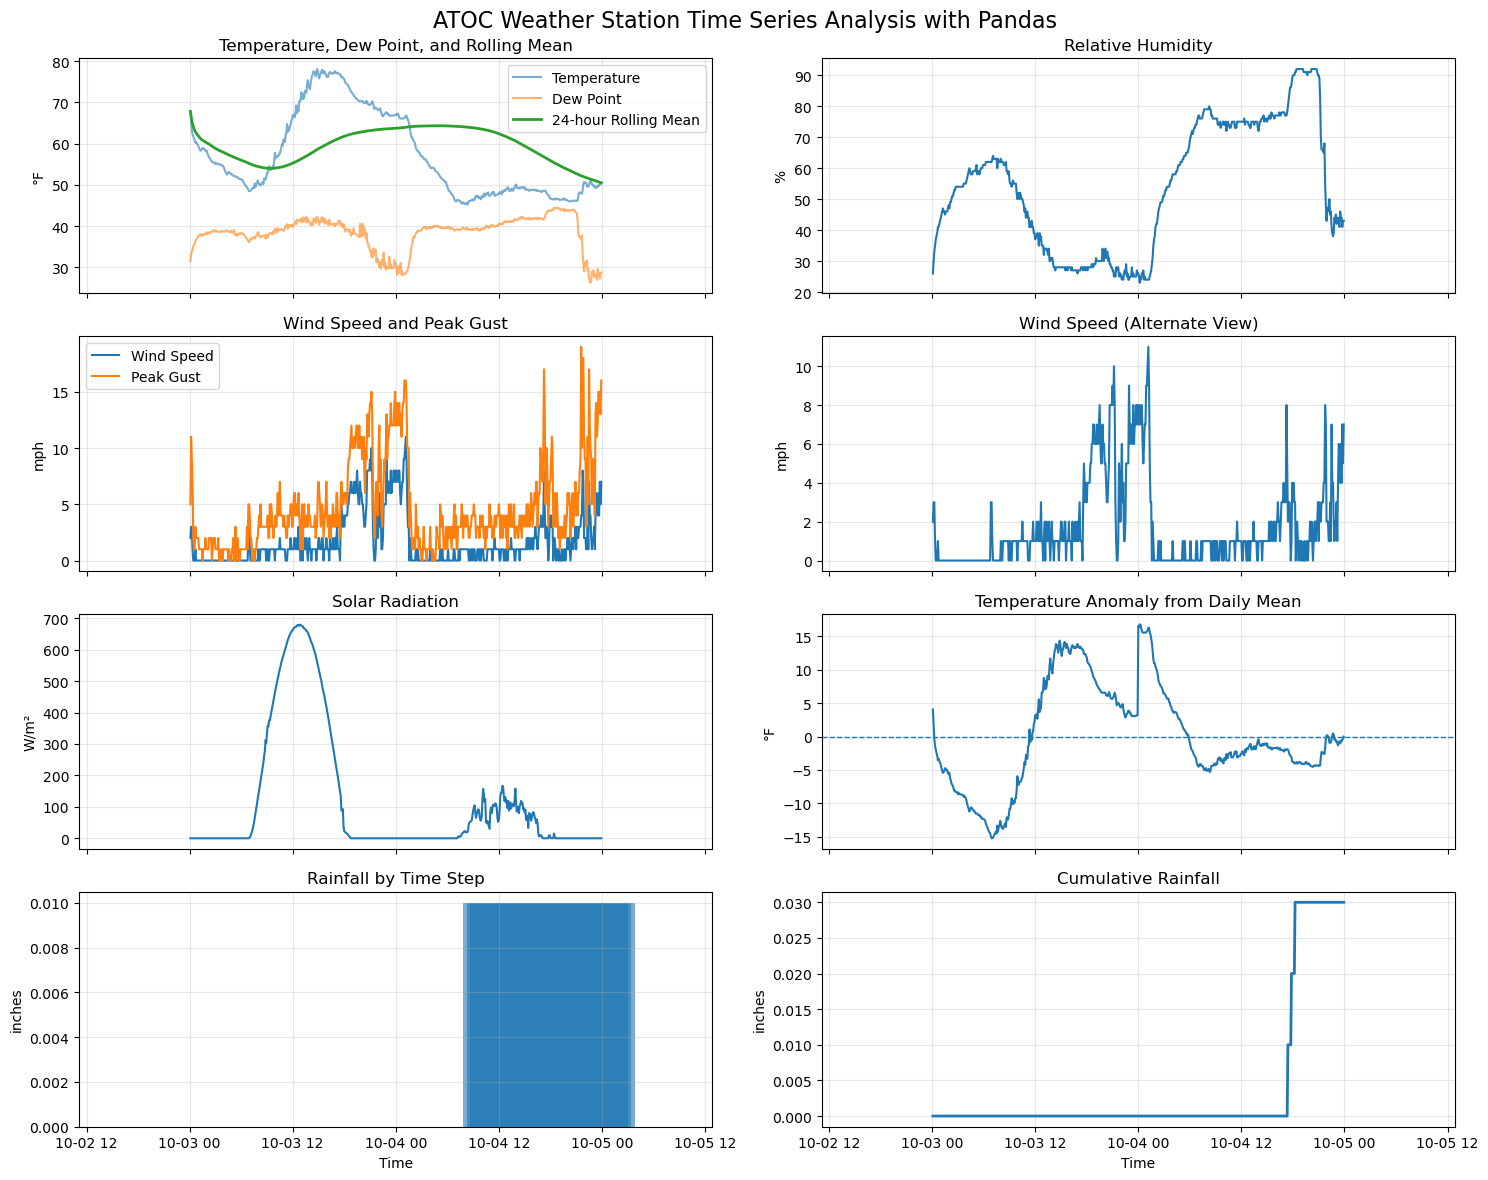

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(15, 12), sharex=True)

# 1. Temperature + dew point + rolling mean
axes[0, 0].plot(weather.index, weather[temp_col], label='Temperature', alpha=0.6)
axes[0, 0].plot(weather.index, weather[dew_col], label='Dew Point', alpha=0.6)
axes[0, 0].plot(weather.index, weather['temp_24h'], label='24-hour Rolling Mean', linewidth=2)
axes[0, 0].set_title('Temperature, Dew Point, and Rolling Mean')
axes[0, 0].set_ylabel('°F')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Humidity
axes[0, 1].plot(weather.index, weather[rh_col])
axes[0, 1].set_title('Relative Humidity')
axes[0, 1].set_ylabel('%')
axes[0, 1].grid(True, alpha=0.3)

# 3. Wind speed + gust
axes[1, 0].plot(weather.index, weather[wind_col], label='Wind Speed')
axes[1, 0].plot(weather.index, weather[gust_col], label='Peak Gust')
axes[1, 0].set_title('Wind Speed and Peak Gust')
axes[1, 0].set_ylabel('mph')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Wind speed
axes[1, 1].plot(weather.index, weather[wind_col])
axes[1, 1].set_title('Wind Speed (Alternate View)')
axes[1, 1].set_ylabel('mph')
axes[1, 1].grid(True, alpha=0.3)

# 5. Solar radiation
axes[2, 0].plot(weather.index, weather[solar_col])
axes[2, 0].set_title('Solar Radiation')
axes[2, 0].set_ylabel('W/m²')
axes[2, 0].grid(True, alpha=0.3)

# 6. Temperature anomaly
axes[2, 1].plot(weather.index, weather['temp_anomaly'])
axes[2, 1].axhline(0, linestyle='--', linewidth=1)
axes[2, 1].set_title('Temperature Anomaly from Daily Mean')
axes[2, 1].set_ylabel('°F')
axes[2, 1].grid(True, alpha=0.3)

# 7. Rain bars
axes[3, 0].bar(weather.index, weather['rain_step'], alpha=0.6)
axes[3, 0].set_title('Rainfall by Time Step')
axes[3, 0].set_ylabel('inches')
axes[3, 0].grid(True, alpha=0.3)

# 8. Cumulative rain
axes[3, 1].plot(weather.index, weather['cumulative_rain'], linewidth=2)
axes[3, 1].set_title('Cumulative Rainfall')
axes[3, 1].set_ylabel('inches')
axes[3, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Time')
axes[-1, 1].set_xlabel('Time')

plt.suptitle('ATOC Weather Station Time Series Analysis with Pandas', fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
fig.savefig('lab6_weather_plot.png', dpi=300, bbox_inches='tight')

In [ ]:
# Lab 6: ATOC Weather Station Time Series Analysis

#This notebook uses pandas to load fixed-width weather station data from the ATOC Sundowner archive, create a datetime index, and visualize multiple variables as time series. I included a 24-hour rolling mean for temperature, a daily temperature anomaly, and cumulative rainfall to demonstrate pandas time-series analysis methods from Lecture 7.